<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Project 1: World Development Statistics - Education Outcomes and Wealth Inequality
*Author: Deval Mehta*

In [1]:
# Import warning ignore to remove unnecessary warnings when using the "inplace = True" kwarg to rewrite dataframes
# Got this from Asha
import warnings
warnings.filterwarnings('ignore')

--- 
# Part 1

Part 1 requires knowledge of basic Python.

---

## Problem Statement

**Current Statement**: Is the covariance of educational outcomes and wealth inequality globally significant enough to warrant further exploration in pursuit of improving education attainment levels in the United States?

**Next Steps Goal**: Can the United States rise above 90% upper secondary education completion within the next decade by reducing disparities in wealth distribution?

### Contents:
- [Background](#Background)
- [Data Import & Cleaning](#Data-Import-and-Cleaning)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Data Visualization](#Visualize-the-Data)
- [Conclusions and Recommendations](#Conclusions-and-Recommendations)

## Background

For our first project, we're going to take a look at World Development Statistics from [Gapminder](https://www.gapminder.org/about/), an independent Swedish foundation that aims to make data about the world more accessible and reliable. A good introduction on Gapminder is this [Ted Talk](https://www.ted.com/talks/hans_rosling_the_best_stats_you_ve_ever_seen) from Hans Rosling, which also shows how effective data visualization can be for your audience.

[The United States spends more per student than any country in the world](https://nces.ed.gov/blogs/nces/post/education-at-a-glance-2023-putting-u-s-data-in-a-global-context) (save Luxembourg), yet we still only have an 87% completion rate for upper secondary education according to the Organization for Economic Cooperation and Development's (OECD) annual [*Education at a Glance*](https://www.oecd-ilibrary.org/sites/e13bef63-en/1/3/3/3/index.html?itemId=/content/publication/e13bef63-en&_csp_=a4f4b3d408c9dd70d167f10de61b8717&itemIGO=oecd&itemContentType=book#annex-d1e22113-dea59c5599) report. Comparatively, Lithuania, who spends about 3/8 as much as the US per student, has a comparable upper secondary completion rate. This suggests that there are other factors at play, including wasted expenditure, which see our educational outcomes stagnating and, in some cases dropping.

Often left unconsidered is the "wealth gap," the disparity in national share of wealth held by those of the most means and those of the fewest. We strive to determine whether educational outcomes and wealth inequality covary significantly enough across the world to warrant further exploration in pursuit of improving education attainment levels in the United States. To do so, we consider literacy rates, duration of compulsary education, and attainment of a Bachelor's degree compared against the share of pretax income held by the 10% of individuals by wealth and the Gini index over the 20 year span from 1998 to 2017.

### Choose your Data

There are 3 datasets included in the [`data`](./data/) folder for this project. You are required to pick **at least two** of these to complete your analysis. Feel free to use more than two if you would like, or add other relevant datasets you find online. 

**HINT: There are more datasets available on the Gapminder website**

* [`population.csv`](./data/population.csv): Population by Country
* [`life_expectancy.csv`](./data/life_expectancy.csv): Life Expectancy by Country
* [`gni_per_cap_atlas_method_con2021.csv`](./data/gni_per_cap_atlas_method_con2021.csv): Gross National Income (GNI) per capita in current US dollars

In addition the datasets provided for the project, the following have been added for the purposes of exploring our specific problem statement.

#### Education Attainment Data
- `duration_compulsary_education.csv`: Duration of Compulsary Education by Country in Years
- `educ_attainment_ba_total.csv`: Percent of Total Population Age 25+ to Attain at Least a Bachelor's by Country
- `educ_attainment_ba_female.csv`: Percent of Female Population Age 25+ to Attain at Least a Bachelor's by Country
- `educ_attainment_ba_male.csv`: Percent of Male Population Age 25+ to Attain at Least a Bachelor's by Country

#### Wealth Inequality Data
- `inequality_index_gini.csv`: The Gini Index by Country
- `wid_pretax_income_share_top10.csv`: The Share of National Wealth Held by the Top 10% Wealthiest Individuals by Country

### Outside Research

Based on your problem statement and your chosen datasets, spend some time doing outside research on state policies or additional information that might be relevant. Summarize your findings below. If you bring in any outside tables or charts, make sure you are explicit about having borrowed them. If you quote any text, make sure that it renders as being quoted. **Make sure that you cite your sources.**

The annual OECD *Education at a Glance* report mentioned in the background section constitutes my outside research. There are other reliable sources for education data as well, but this is likely the only one to which we will refer.

### Coding Challenges

1. Manually calculate mean:

    Write a function that takes in values and returns the mean of the values. Create a list of numbers that you test on your function to check to make sure your function works!
    
    *Note*: Do not use any mean methods built-in to any Python libraries to do this! This should be done without importing any additional libraries.

In [2]:
# Defining a mean function manually. Mean = Sum/Length for a list.
def mean(number_list):
    return sum(number_list)/len(number_list)

my_list = [1, 4, 8, 0, -9, 3, 7, 81, 15, -60, -50]
mean(my_list)

0.0

2. Manually calculate standard deviation:

    The formula for standard deviation is below:

    $$\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^n(x_i - \mu)^2}$$

    Where $x_i$ represents each value in the dataset, $\mu$ represents the mean of all values in the dataset and $n$ represents the number of values in the dataset.

    Write a function that takes in values and returns the standard deviation of the values using the formula above. Hint: use the function you wrote above to calculate the mean! Use the list of numbers you created above to test on your function.
    
    *Note*: Do not use any standard deviation methods built-in to any Python libraries to do this! This should be done without importing any additional libraries.

In [3]:
# Manually create a standard deviation function using the formula above.
# We can use the mean function to write the standard deviation function, since we have it.
def stdev(number_list):
    point_deviations_squared = [(number - mean(number_list)) ** 2 for number in number_list] # Create a list of point deviations and squaring them to be added together
    return (mean(point_deviations_squared)) ** 0.5 # Taking the sum and then dividing by the length of the point deviations squared is the same as taking their mean, so we apply the mean function again.

stdev(my_list)

34.51745276602179

3. Data cleaning function:
    
    Write a function that takes in a string consisting a number and an abbreviated place value (ex. '5M', '45K'), and converts that string to an integer. For example, inputting '5M' in your function should return 5000000, '45K' should return 45000, etc. Make sure to test your function to make sure it works!

You will use these functions later on in the project!

In [4]:
# Let's take a look at the population data and clean that.
# We will assume that there are no numbers of value 1T or greater being evaluated.
def abbrev_num_to_float(abbrev_number):
    if abbrev_number[-1] not in '0123456789':                       # Check to see whether the final character is a number
        suffix = abbrev_number[-1]                                  # Isolate the final character as the suffix
        prefix_as_float = float(abbrev_number.replace(suffix, ''))  # Remove the suffix if it is not numeric
    else:
        suffix = 0                                                  # Overwrite the suffix with the number0
        
    if suffix.upper() == 'B':                                       # Case 1: Billions
        return prefix_as_float * 1_000_000_000
    elif suffix.upper() == 'M':                                     # Case 2: Millions
        return prefix_as_float * 1_000_000
    elif suffix.lower() == 'k':                                     # Case 3: Thousands
        return prefix_as_float * 1_000
    elif suffix == 0:                                               # Case 4: No suffix
        return prefix_as_float
    else:
        return "This number is too large"

abbrev_num_to_float('150M'), abbrev_num_to_float('150k'), abbrev_num_to_float('150b'), abbrev_num_to_float('150B'), abbrev_num_to_float('150K')

(150000000.0, 150000.0, 150000000000.0, 150000000000.0, 150000.0)

--- 
# Part 2

Part 2 requires knowledge of Pandas, EDA, data cleaning, and data visualization.

---

*All libraries used should be added here*

In [5]:
# Import all necessary libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Import and Cleaning

### Data Import & Cleaning

Import the datasets that you selected for this project and go through the following steps at a minimum. You are welcome to do further cleaning as you feel necessary:
1. Display the data: print the first 5 rows of each dataframe to your Jupyter notebook.
2. Check for missing values.
3. Check for any obvious issues with the observations (keep in mind reasonable values for each column).
4. Fix any errors you identified in steps 2-3.
5. Display the data types of each feature.
6. Fix any incorrect data types found in step 5.
    - Fix any individual values preventing other columns from being the appropriate type.
    - If your dataset has a column of abbreviated numbers (ex. '3M', '45K', etc.), use the function you wrote in Part 1 (coding challenges, number 3) to convert this to integers! *Hint*: use `.map()` or `.apply()`.
7. Rename Columns.
    - Column names should be all lowercase.
    - Column names should not contain spaces (underscores will suffice--this allows for using the `df.column_name` method to access columns in addition to `df['column_name']`).
    - Column names should be unique and informative.
8. Drop unnecessary rows (if needed).
9. Merge dataframes that can be merged.
10. Perform any additional cleaning that you feel is necessary.
11. Save your cleaned and merged dataframes as csv files.

In [6]:
# Let's import all of the datasets we need.
duration_compulsary_education = pd.read_csv('./data/duration_compulsary_education.csv')
educ_attainment_ba_female = pd.read_csv('./data/educ_attainment_ba_female.csv')
educ_attainment_ba_male = pd.read_csv('./data/educ_attainment_ba_male.csv')
educ_attainment_ba_total = pd.read_csv('./data/educ_attainment_ba_total.csv')
gini_index = pd.read_csv('./data/inequality_index_gini.csv')
wid_pretax_income_share_top10 = pd.read_csv('./data/wid_pretax_income_share_top10.csv')

In [7]:
# We can save all the dataframes to a list to make the upcoming steps faster
df_list = [duration_compulsary_education,
           educ_attainment_ba_female,
           educ_attainment_ba_male,
           educ_attainment_ba_total,
           gini_index,
           wid_pretax_income_share_top10]

In [8]:
# Since we're only interested in the 20 year span from 1998 to 2017, let's check the column names to allow ourselves to isolate them
for df in df_list:
    print(df.columns)


Index(['country', '1975', '1976', '1977', '1978', '1979', '1980', '1981',
       '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990',
       '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
       '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023'],
      dtype='object')
Index(['country', '1970', '1971', '1972', '1973', '1974', '1975', '1976',
       '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985',
       '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994',
       '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       '2022', '2023'],
      dtype='object')
Index(['country',

In [9]:
#It seems they're all titled as strings. Let's remove all columns that don't have to do with our years of interest.
data_of_interest = ['country']            # Create a new list of the columns of interest
data_of_interest.extend([str(year) for year in range(1998, 2018)]) # Succinctly define a list of strings that will be callable for our column names
trimmed_dfs = []                                              # Initialize an empty list to hold the trimmed dataframes
for df in df_list:
    trimmed_dfs.append(df[data_of_interest])

for df in trimmed_dfs:
    print(df.head())

# To make these easier to call, let's also save them as new variables
[trimmed_duration_compulsary_education,
 trimmed_educ_attainment_ba_female,
 trimmed_educ_attainment_ba_male,
 trimmed_educ_attainment_ba_total,
 trimmed_gini_index,
 trimmed_wid_pretax_income_share_top10] = trimmed_dfs

       country  1998  1999  2000  2001  2002  2003  2004  2005  2006  ...  \
0        Aruba   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
1  Afghanistan   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0  ...   
2       Angola   4.0   4.0   4.0   4.0   4.0   4.0   4.0   4.0   4.0  ...   
3      Albania   8.0   8.0   8.0   8.0   8.0   8.0   8.0   8.0   8.0  ...   
4      Andorra  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  ...   

   2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  
0   NaN   NaN   NaN  13.0  13.0  13.0  13.0  13.0  13.0  13.0  
1   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0  
2   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0  
3   8.0   8.0   8.0   8.0   9.0   9.0   9.0   9.0   9.0   9.0  
4  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  

[5 rows x 21 columns]
       country  1998  1999  2000  2001   2002  2003    2004    2005  2006  \
0        Aruba   NaN   NaN  14.7   NaN    NaN   NaN  

In [10]:
# Now we can proceed with the remaining prompts. Let's start by checking for null values.
for df in trimmed_dfs:
    print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  199 non-null    object 
 1   1998     156 non-null    float64
 2   1999     162 non-null    float64
 3   2000     164 non-null    float64
 4   2001     168 non-null    float64
 5   2002     170 non-null    float64
 6   2003     172 non-null    float64
 7   2004     178 non-null    float64
 8   2005     180 non-null    float64
 9   2006     180 non-null    float64
 10  2007     182 non-null    float64
 11  2008     185 non-null    float64
 12  2009     186 non-null    float64
 13  2010     190 non-null    float64
 14  2011     191 non-null    float64
 15  2012     191 non-null    float64
 16  2013     193 non-null    float64
 17  2014     193 non-null    float64
 18  2015     195 non-null    float64
 19  2016     196 non-null    float64
 20  2017     196 non-null    float64
dtypes: float64(20), 

In [11]:
# It seems like some of our datasets do not include information on every country
# To address this, it will make the most sense to limit our analysis to the top 10 and bottom 10 countries by Gini index for which we have data.
# We'll first check for the countries which have mostly intact Gini coefficiant data
trimmed_gini_index.dropna(how = 'any', inplace = True)
trimmed_gini_index

# Only 15 countries have complete Gini index data for the past decade, but they span quite a range in terms of inequality
# The Gini index does not have much variation across time for any of the countries for which the data is complete.
# That means we can reliably sort by the mean value for each country.
# We'll only use data from these 15 countries in the other dataframes

,country,1998,1999,2000,2001,2002,2003,2004,2005,2006,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
15,Belarus,32.0,31.7,31.2,30.6,30.3,28.8,26.5,27.6,28.3,...,27.8,27.7,28.6,27.2,26.5,26.6,27.2,25.6,25.3,25.4
22,Canada,33.2,33.1,33.4,33.6,33.6,33.8,33.8,33.6,34.1,...,33.9,34.0,33.6,32.7,33.5,33.8,33.2,33.7,32.7,33.3
33,Costa Rica,45.7,47.7,47.4,51.5,51.8,49.3,48.4,47.5,49.3,...,48.6,50.6,48.0,48.8,48.4,49.2,48.6,48.4,48.7,48.3
36,Germany,28.1,29.0,28.8,29.9,29.9,29.9,30.2,31.6,31.0,...,30.9,30.5,30.3,30.7,31.1,31.5,30.9,31.4,31.4,31.9
48,France,31.7,32.5,32.6,32.5,31.8,31.4,30.6,29.8,29.7,...,33.0,32.7,33.7,33.3,33.1,32.5,32.3,32.7,31.9,31.6
51,UK,36.6,36.8,38.8,37.1,35.1,34.9,34.8,35.5,35.9,...,35.4,35.1,33.7,33.2,33.1,32.7,33.1,33.3,33.1,32.6
52,Georgia,41.3,40.1,40.5,39.6,37.2,36.7,36.2,37.4,36.9,...,38.5,38.2,39.5,39.6,39.0,38.6,37.6,36.5,36.6,37.9
65,Indonesia,32.2,32.1,29.5,30.0,32.8,33.0,33.9,34.1,35.3,...,36.1,36.0,37.2,40.5,40.5,40.8,40.2,40.4,39.3,38.8
89,Luxembourg,30.6,30.0,30.1,30.9,31.0,30.2,30.2,30.8,30.9,...,32.6,31.2,30.5,32.1,34.3,32.0,31.2,32.9,31.7,34.5
92,Moldova,39.5,42.6,36.4,38.0,35.8,34.9,35.0,36.3,35.4,...,34.7,32.9,32.1,30.6,29.2,28.5,26.8,27.0,26.3,25.9


In [12]:
# This is jumping the gun a little, but let's see how the countries rank in order from most to least equal by Gini index
# Since the mean is relatively reliable here, we'll take the mean across our years of interest and sort by that.
# To take the mean, we'll first have to set the indexes to be the country names

trimmed_gini_index.set_index('country', inplace = True)
trimmed_gini_index['time_averaged_value'] = trimmed_gini_index.mean(axis = 1)
trimmed_gini_index.sort_values(by = 'time_averaged_value', inplace = True)
trimmed_gini_index

,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,time_averaged_value
country,,,,,,,,,,,,,,,,,,,,,
Belarus,32.0,31.7,31.2,30.6,30.3,28.8,26.5,27.6,28.3,29.6,...,27.7,28.6,27.2,26.5,26.6,27.2,25.6,25.3,25.4,28.225
Germany,28.1,29.0,28.8,29.9,29.9,29.9,30.2,31.6,31.0,31.1,...,30.5,30.3,30.7,31.1,31.5,30.9,31.4,31.4,31.9,30.505
Luxembourg,30.6,30.0,30.1,30.9,31.0,30.2,30.2,30.8,30.9,31.1,...,31.2,30.5,32.1,34.3,32.0,31.2,32.9,31.7,34.5,31.440
France,31.7,32.5,32.6,32.5,31.8,31.4,30.6,29.8,29.7,32.4,...,32.7,33.7,33.3,33.1,32.5,32.3,32.7,31.9,31.6,32.090
Moldova,39.5,42.6,36.4,38.0,35.8,34.9,35.0,36.3,35.4,34.4,...,32.9,32.1,30.6,29.2,28.5,26.8,27.0,26.3,25.9,33.115
Canada,33.2,33.1,33.4,33.6,33.6,33.8,33.8,33.6,34.1,33.8,...,34.0,33.6,32.7,33.5,33.8,33.2,33.7,32.7,33.3,33.520
UK,36.6,36.8,38.8,37.1,35.1,34.9,34.8,35.5,35.9,34.4,...,35.1,33.7,33.2,33.1,32.7,33.1,33.3,33.1,32.6,34.760
Indonesia,32.2,32.1,29.5,30.0,32.8,33.0,33.9,34.1,35.3,36.7,...,36.0,37.2,40.5,40.5,40.8,40.2,40.4,39.3,38.8,35.970
Georgia,41.3,40.1,40.5,39.6,37.2,36.7,36.2,37.4,36.9,38.1,...,38.2,39.5,39.6,39.0,38.6,37.6,36.5,36.6,37.9,38.300


In [13]:
# Let's pull the countries from this dataframe and save them as a list that we can use to pull slices of the other relevant dataframes
countries_of_interest = list(trimmed_gini_index.index.values)
countries_of_interest.remove('Peru') # We remove Peru from the list, as at least one of the remaining data sets we're using does not have any data for Peru

In [14]:
# We'll use the list we just created to keep only the rows corresponding to the countries therein
def trim_to_countries_of_interest(df):
    df.set_index('country', inplace = True)
    return df.loc[countries_of_interest]

# We want to use a for loop to go through the list of dataframes, but that isn't working, so I just have to do this one by one

trimmed_duration_compulsary_education = trim_to_countries_of_interest(trimmed_duration_compulsary_education)
trimmed_educ_attainment_ba_female = trim_to_countries_of_interest(trimmed_educ_attainment_ba_female)
trimmed_educ_attainment_ba_male = trim_to_countries_of_interest(trimmed_educ_attainment_ba_male)
trimmed_educ_attainment_ba_total = trim_to_countries_of_interest(trimmed_educ_attainment_ba_total)
trimmed_gini_index = trimmed_gini_index.loc[countries_of_interest].drop('time_averaged_value', axis = 1)
trimmed_wid_pretax_income_share_top10 = trim_to_countries_of_interest(trimmed_wid_pretax_income_share_top10)

# In defining the dataframes this way, we also ensure that they are all sorted from lowest to highest Gini index.

In [15]:
# With all of our data trimmed down, let's take another look for datatypes and null values
final_dfs = [trimmed_duration_compulsary_education,
             trimmed_educ_attainment_ba_female,
             trimmed_educ_attainment_ba_male,
             trimmed_educ_attainment_ba_total,
             trimmed_gini_index,
             trimmed_wid_pretax_income_share_top10]

for df in final_dfs:
    print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, Belarus to Panama
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1998    13 non-null     float64
 1   1999    13 non-null     float64
 2   2000    13 non-null     float64
 3   2001    13 non-null     float64
 4   2002    14 non-null     float64
 5   2003    14 non-null     float64
 6   2004    14 non-null     float64
 7   2005    14 non-null     float64
 8   2006    14 non-null     float64
 9   2007    14 non-null     float64
 10  2008    14 non-null     float64
 11  2009    14 non-null     float64
 12  2010    14 non-null     float64
 13  2011    14 non-null     float64
 14  2012    14 non-null     float64
 15  2013    14 non-null     float64
 16  2014    14 non-null     float64
 17  2015    14 non-null     float64
 18  2016    14 non-null     float64
 19  2017    14 non-null     float64
dtypes: float64(20)
memory usage: 2.3+ KB
None
<class 'pandas.core.frame.DataF

In [16]:
# Quite a bit of our education data is null.
# It doesn't make sense to assume the values are 0 when there is no data, as that would skew the summary statistics.
# To ensure calculations can still be done, we'll fill all unavailable data with 'np.nan'
# The lack of availability of relevant data poses a challenge and we will perhaps have to consdier other sources 

for df in final_dfs:
    df.fillna(np.nan, inplace = True)

In [17]:
for df in final_dfs:
    df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, Belarus to Panama
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1998    13 non-null     float64
 1   1999    13 non-null     float64
 2   2000    13 non-null     float64
 3   2001    13 non-null     float64
 4   2002    14 non-null     float64
 5   2003    14 non-null     float64
 6   2004    14 non-null     float64
 7   2005    14 non-null     float64
 8   2006    14 non-null     float64
 9   2007    14 non-null     float64
 10  2008    14 non-null     float64
 11  2009    14 non-null     float64
 12  2010    14 non-null     float64
 13  2011    14 non-null     float64
 14  2012    14 non-null     float64
 15  2013    14 non-null     float64
 16  2014    14 non-null     float64
 17  2015    14 non-null     float64
 18  2016    14 non-null     float64
 19  2017    14 non-null     float64
dtypes: float64(20)
memory usage: 2.3+ KB
<class 'pandas.core.frame.DataFrame'

In [18]:
# Finallly, let's write our data to .csv files.
trimmed_duration_compulsary_education.to_csv('./data/trimmed_duration_compulsary_education.csv')
trimmed_educ_attainment_ba_female.to_csv('./data/trimmed_educ_attainment_ba_female.csv')
trimmed_educ_attainment_ba_male.to_csv('./data/trimmed_educ_attainment_ba_male.csv')
trimmed_educ_attainment_ba_total.to_csv('./data/trimmed_educ_attainment_ba_total.csv')
trimmed_gini_index.to_csv('./data/trimmed_gini_index.csv')
trimmed_wid_pretax_income_share_top10.to_csv('./data/trimmed_wid_pretax_income_share_top10.csv')

### Data Dictionary

Now that we've fixed our data, and given it appropriate names, let's create a [data dictionary](http://library.ucmerced.edu/node/10249). 

A data dictionary provides a quick overview of features/variables/columns, alongside data types and descriptions. The more descriptive you can be, the more useful this document is.

Example of a Fictional Data Dictionary Entry: 

|Feature|Type|Dataset|Description|
|---|---|---|---|
|**county_pop**|*integer*|2010 census|The population of the county (units in thousands, where 2.5 represents 2500 people).| 
|**per_poverty**|*float*|2010 census|The percent of the county over the age of 18 living below the 200% of official US poverty rate (units percent to two decimal places 98.10 means 98.1%)|

[Here's a quick link to a short guide for formatting markdown in Jupyter notebooks](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html).

Provided is the skeleton for formatting a markdown table, with columns headers that will help you create a data dictionary to quickly summarize your data, as well as some examples. **This would be a great thing to copy and paste into your custom README for this project.**

*Note*: if you are unsure of what a feature is, check the source of the data! This can be found in the README.

All the data we have now is formatted the same way: every column stores floats, other than the country and each column represents a year in the span from 1998 to 2017. This will help simplify the data dictionary. We have isolated our analysis to the following countries:

- Belarus
- Canada
- Costa Rica
- El Salvador
- France
- Georgia
- Germany
- Indonesia
- Luxembourg
- Moldova
- Panama
- Russia
- UK
- USA

|Dataset|Type|Description|
|---|---|---|
|trimmed_duration_compulsary_education|float|Number of years of compulsary education by year.|
|trimmed_educ_attainment_ba_total|float|Percent of national population age 25 and older who hold at least a Bachelor's Degree by year.|
|trimmed_educ_attainment_ba_female|float|Percent of women age 25 and older who hold at least a Bachelor's Degree by year.|
|trimmed_educ_attainment_ba_male|float|Percent of men age 25 and older who hold at least a Bachelor's Degree by year.|
|trimmed_gini_index|float|[Gini Index](https://ourworldindata.org/what-is-the-gini-coefficient) by year, a measure of wealth inequality.
|trimmed_wid_pretax_income_share_top10|float|Percent share of national wealth held by the wealthiest 10% of individuals by year|

## Exploratory Data Analysis

Complete the following steps to explore your data. You are welcome to do more EDA than the steps outlined here as you feel necessary:
1. Summary Statistics.
2. Use a **dictionary comprehension** to apply the standard deviation function you create in part 1 to each numeric column in one of your dataframes.  **No loops**.
    - Assign the output to variable `sd` as a dictionary where: 
        - Each column name is now a key 
        - That standard deviation of the column is the value
        - *Example Output :* `{'1801': 3.80, '1802': 3.93, ...}`
3. Investigate trends in the data.
    - Using sorting and/or masking (along with the `.head()` method to avoid printing our entire dataframe), consider questions relevant to your problem statement. Some examples are provided below (but feel free to change these questions for your specific problem):
        - Which states have the highest and lowest populations for the past few decades?
        - Which states have the highest and lowest economic growth over the course of the dataset?
        - What years were there new countries created?
        - Do any countries have higher growth rates of population than their economy?
        - Which countries have had the lowest population growth?
    - **You should comment on your findings at each step in a markdown cell below your code block**. Make sure you include at least one example of sorting your dataframe by a column, and one example of using boolean filtering (i.e., masking) to select a subset of the dataframe.

In [19]:
# Summary Statistics:
for df in final_dfs:
    print(df.describe(include = 'all'))

            1998       1999       2000       2001       2002       2003  \
count  13.000000  13.000000  13.000000  13.000000  14.000000  14.000000   
mean   10.000000  10.000000  10.000000  10.000000   9.928571   9.928571   
std     1.825742   1.825742   1.825742   1.825742   1.774360   1.774360   
min     6.000000   6.000000   6.000000   6.000000   6.000000   6.000000   
25%     9.000000   9.000000   9.000000   9.000000   9.000000   9.000000   
50%    10.000000  10.000000  10.000000  10.000000  10.000000  10.000000   
75%    11.000000  11.000000  11.000000  11.000000  11.000000  11.000000   
max    13.000000  13.000000  13.000000  13.000000  13.000000  13.000000   

            2004       2005       2006       2007       2008       2009  \
count  14.000000  14.000000  14.000000  14.000000  14.000000  14.000000   
mean   10.000000  10.214286  10.214286  10.214286  10.214286  10.285714   
std     1.709701   1.311404   1.311404   1.311404   1.311404   1.382783   
min     6.000000   9.000

In [20]:
# Perfomring standard deviation on the Gini Index Using the SD function above:
sd = {year: stdev(trimmed_gini_index[year]) for year in trimmed_gini_index.columns[1:]}
sd

{'1999': 8.17832189263738,
 '2000': 8.223721288853039,
 '2001': 8.46599741583341,
 '2002': 8.407042723035179,
 '2003': 8.137018583521328,
 '2004': 7.822103689062743,
 '2005': 7.47170171584842,
 '2006': 7.4638345728326705,
 '2007': 6.888651566755519,
 '2008': 6.944829966623094,
 '2009': 7.117945845623194,
 '2010': 6.611508210410581,
 '2011': 6.860523720116832,
 '2012': 6.905986755071609,
 '2013': 7.216113629812612,
 '2014': 7.066390701837849,
 '2015': 6.9800590606237645,
 '2016': 7.10517560713057,
 '2017': 6.864107326357528}

In [21]:
# Because all of our data is numeric and the each row and column are unique, the only interesting aggregates will be taking basic statistics by country over time
trimmed_duration_compulsary_education.mean(axis=1, numeric_only = True)

country
Belarus         9.00
Germany        13.00
Luxembourg     11.45
France         10.00
Moldova         9.20
Canada         10.00
UK             11.00
Indonesia       9.00
Georgia         7.95
Russia          9.20
USA            12.00
El Salvador    10.35
Costa Rica     11.70
Panama         11.00
dtype: float64

In [22]:
trimmed_gini_index.mean(axis = 1, numeric_only = True)

country
Belarus        28.225
Germany        30.505
Luxembourg     31.440
France         32.090
Moldova        33.115
Canada         33.520
UK             34.760
Indonesia      35.970
Georgia        38.300
Russia         39.275
USA            40.715
El Salvador    46.155
Costa Rica     48.775
Panama         53.360
dtype: float64

In [23]:
trimmed_wid_pretax_income_share_top10.mean(axis = 1, numeric_only = True)

country
Belarus        33.515000
Germany        34.955000
Luxembourg     35.925000
France         31.940000
Moldova        33.550000
Canada         38.690000
UK             36.530000
Indonesia      40.695000
Georgia        33.515000
Russia         47.770000
USA            43.525000
El Salvador    48.494444
Costa Rica     50.212500
Panama         51.443750
dtype: float64

In [24]:
trimmed_educ_attainment_ba_total.max(axis = 1, numeric_only = True)

country
Belarus        22.00
Germany        25.90
Luxembourg     34.50
France         18.00
Moldova        20.10
Canada         27.90
UK             33.90
Indonesia       8.79
Georgia        34.70
Russia         59.30
USA            33.40
El Salvador     7.12
Costa Rica     22.80
Panama         20.70
dtype: float64

Since the data is already sorted by lowest to highest levels of wealth inequality, we see that the compulsary education level varies greatly, even just from the aggregate. There appears to be no clear correlation between wealth inequality and duration of compulsary education. On the other hand, we see relatively high levels of Bachelor's attainment for countries with middling levels of wealth inequality, save one exception.

## Visualize the Data

There's not a magic bullet recommendation for the right number of plots to understand a given dataset, but visualizing your data is *always* a good idea. Not only does it allow you to quickly convey your findings (even if you have a non-technical audience), it will often reveal trends in your data that escaped you when you were looking only at numbers. It is important to not only create visualizations, but to **interpret your visualizations** as well.

**Every plot should**:
- Have a title
- Have axis labels
- Have appropriate tick labels
- Text is legible in a plot
- Plots demonstrate meaningful and valid relationships
- Have an interpretation to aid understanding

Here is an example of what your plots should look like following the above guidelines. Note that while the content of this example is unrelated, the principles of visualization hold:

![](https://snag.gy/hCBR1U.jpg)
*Interpretation: The above image shows that as we increase our spending on advertising, our sales numbers also tend to increase. There is a positive correlation between advertising spending and sales.*

---

Here are some prompts to get you started with visualizations. Feel free to add additional visualizations as you see fit:
1. Use Seaborn's heatmap with pandas `.corr()` to visualize correlations between all numeric features.
    - Heatmaps are generally not appropriate for presentations, and should often be excluded from reports as they can be visually overwhelming. **However**, they can be extremely useful in identify relationships of potential interest (as well as identifying potential collinearity before modeling).
    - Please take time to format your output, adding a title. Look through some of the additional arguments and options. (Axis labels aren't really necessary, as long as the title is informative).
2. Visualize distributions using histograms. If you have a lot, consider writing a custom function and use subplots.
    - *OPTIONAL*: Summarize the underlying distributions of your features (in words & statistics)
         - Be thorough in your verbal description of these distributions.
         - Be sure to back up these summaries with statistics.
         - We generally assume that data we sample from a population will be normally distributed. Do we observe this trend? Explain your answers for each distribution and how you think this will affect estimates made from these data.
3. Plot and interpret boxplots. 
    - Boxplots demonstrate central tendency and spread in variables. In a certain sense, these are somewhat redundant with histograms, but you may be better able to identify clear outliers or differences in IQR, etc.
    - Multiple values can be plotted to a single boxplot as long as they are of the same relative scale (meaning they have similar min/max values).
    - Each boxplot should:
        - Only include variables of a similar scale
        - Have clear labels for each variable
        - Have appropriate titles and labels
4. Plot and interpret scatter plots to view relationships between features. Feel free to write a custom function, and subplot if you'd like. Functions save both time and space.
    - Your plots should have:
        - Two clearly labeled axes
        - A proper title
        - Colors and symbols that are clear and unmistakable
5. Additional plots of your choosing.
    - Are there any additional trends or relationships you haven't explored? Was there something interesting you saw that you'd like to dive further into? It's likely that there are a few more plots you might want to generate to support your narrative and recommendations that you are building toward. **As always, make sure you're interpreting your plots as you go**.

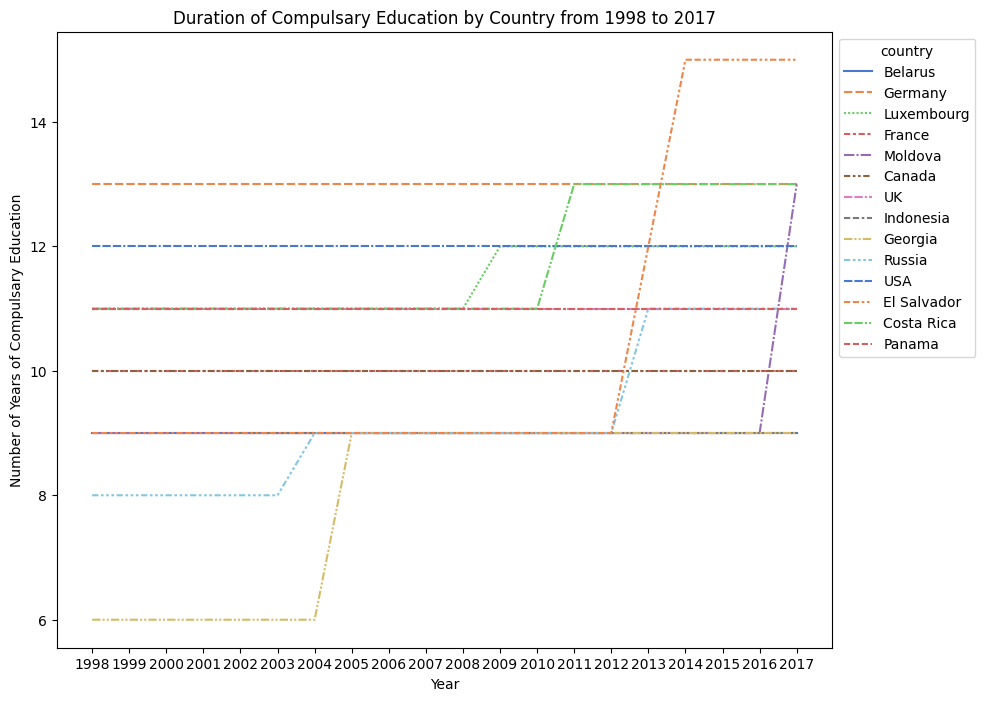

In [39]:
# We'll begin by visually exploring the distribution of the major data sets
plt.figure(figsize = (10, 8))
ax1 = sns.lineplot(data = trimmed_duration_compulsary_education.T, palette = 'muted')
plt.title('Duration of Compulsary Education by Country from 1998 to 2017')
plt.xlabel('Year')
plt.ylabel('Number of Years of Compulsary Education')
sns.move_legend(ax1, "upper left", bbox_to_anchor = (1,1));

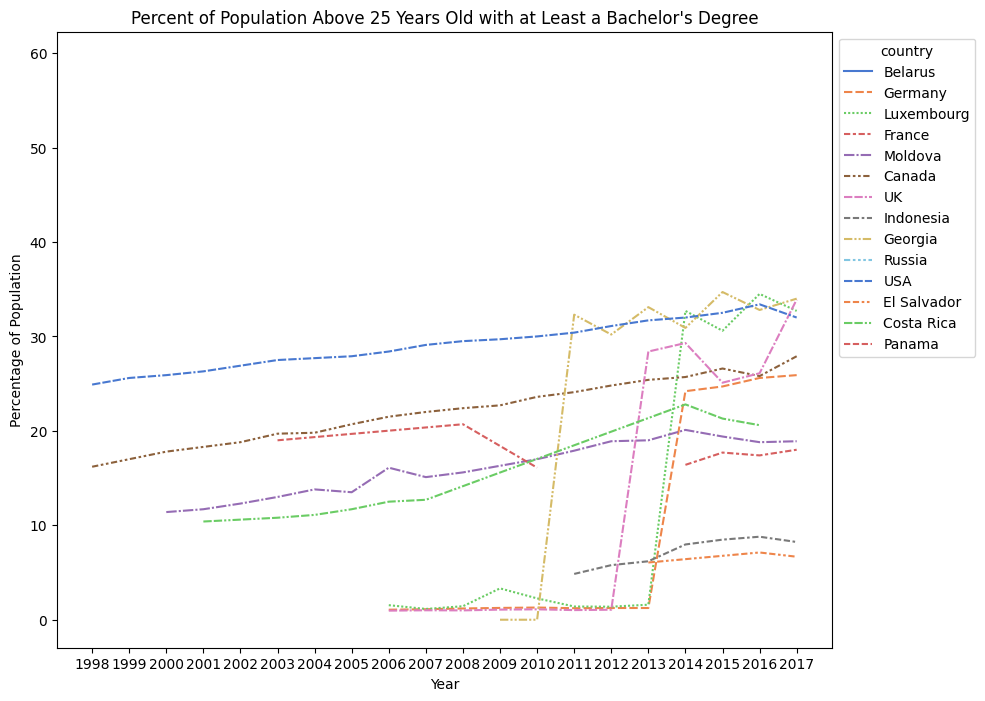

In [45]:
plt.figure(figsize = (10,8))
ax2 = sns.lineplot(data = trimmed_educ_attainment_ba_total.T, palette = 'muted')
plt.title("Percent of Population Above 25 Years Old with at Least a Bachelor's Degree")
plt.xlabel('Year')
plt.ylabel('Percentage of Population')
sns.move_legend(ax2, "upper left", bbox_to_anchor = (1,1));

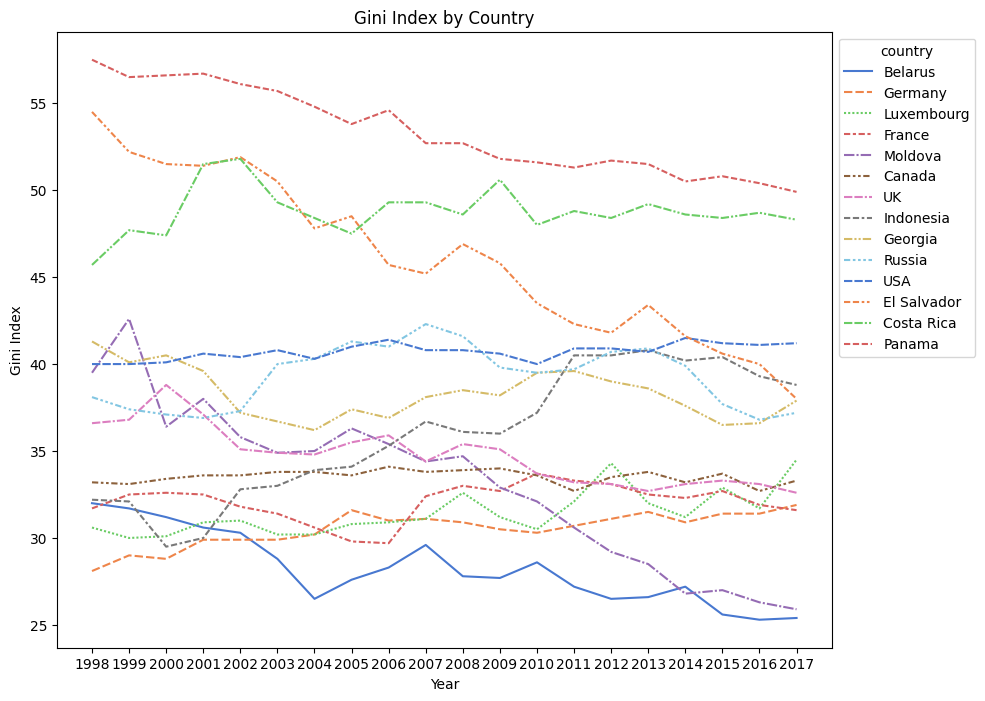

In [41]:
plt.figure(figsize = (10, 8))
ax3 = sns.lineplot(data = trimmed_gini_index.T, palette = 'muted')
plt.title('Gini Index by Country')
plt.xlabel('Year')
plt.ylabel('Gini Index')
sns.move_legend(ax3, "upper left", bbox_to_anchor = (1,1));

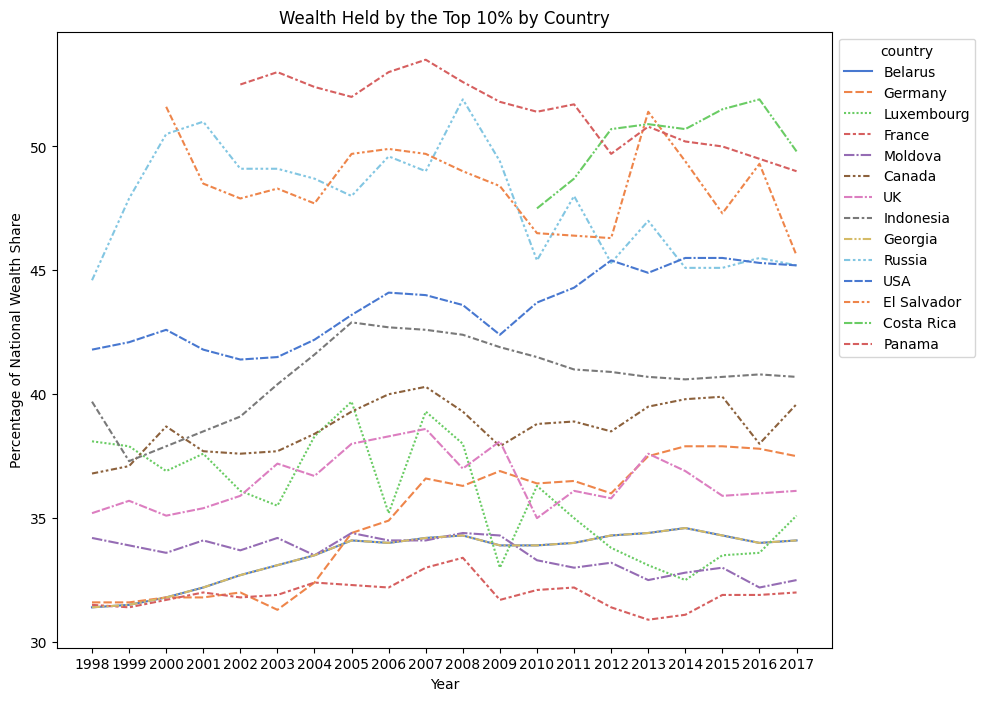

In [43]:
plt.figure(figsize = (10, 8))
ax4 = sns.lineplot(data = trimmed_wid_pretax_income_share_top10.T, palette = 'muted')
plt.title('Wealth Held by the Top 10% by Country')
plt.xlabel('Year')
plt.ylabel('Percentage of National Wealth Share')
sns.move_legend(ax4, "upper left", bbox_to_anchor = (1,1));

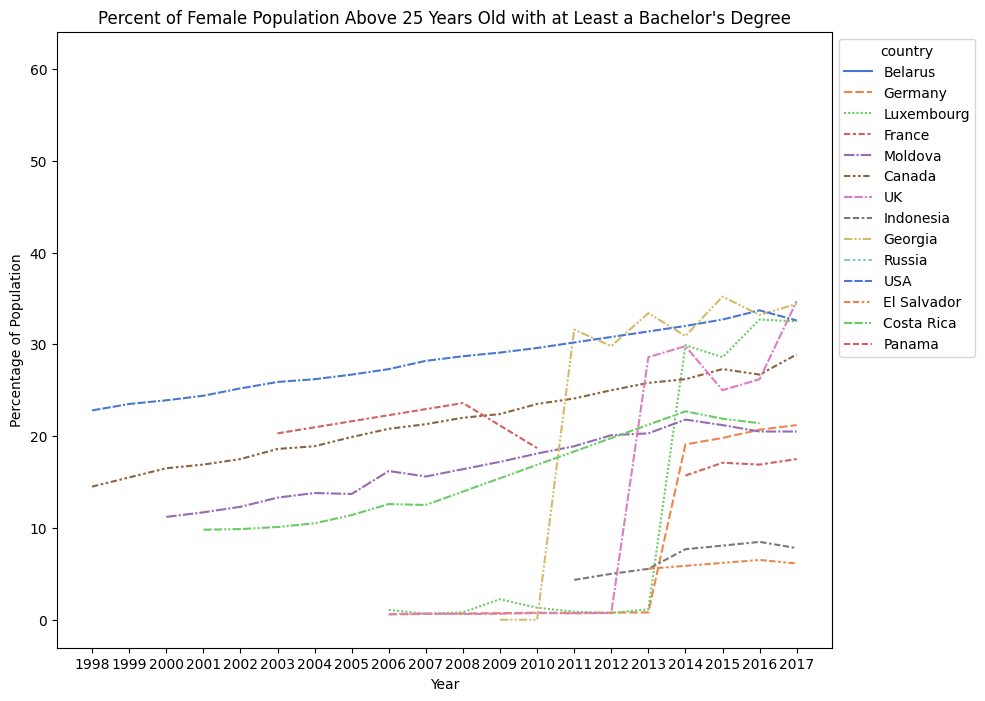

In [49]:
plt.figure(figsize = (10,8))
ax5 = sns.lineplot(data = trimmed_educ_attainment_ba_female.T, palette = 'muted')
plt.title("Percent of Female Population Above 25 Years Old with at Least a Bachelor's Degree")
plt.xlabel('Year')
plt.ylabel('Percentage of Population')
sns.move_legend(ax5, "upper left", bbox_to_anchor = (1,1));

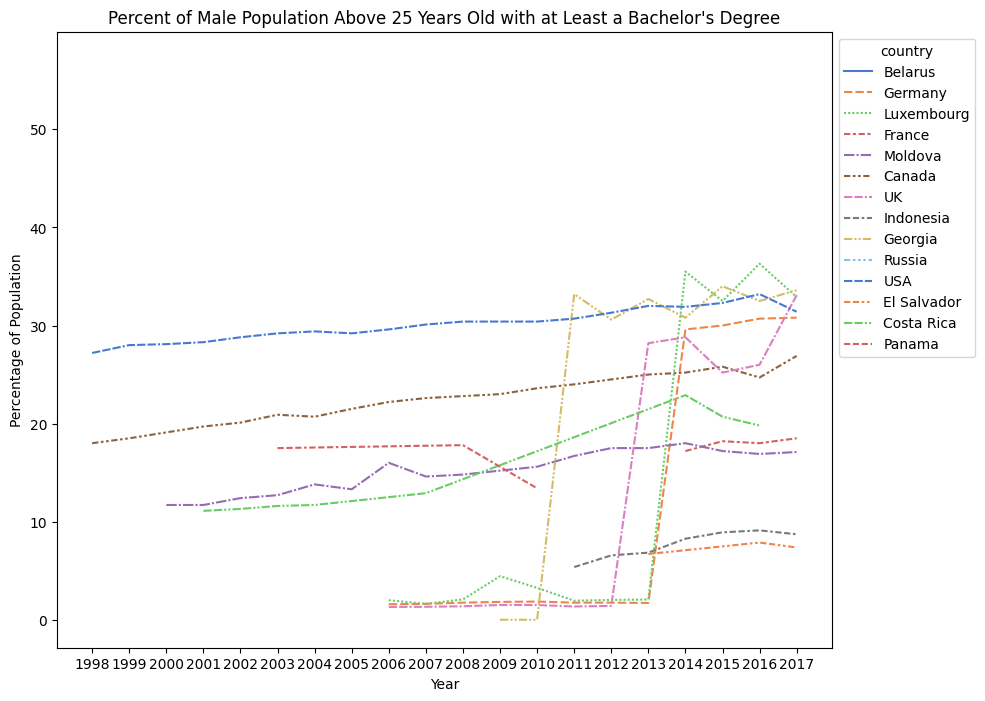

In [48]:
plt.figure(figsize = (10,8))
ax6 = sns.lineplot(data = trimmed_educ_attainment_ba_male.T, palette = 'muted')
plt.title("Percent of Male Population Above 25 Years Old with at Least a Bachelor's Degree")
plt.xlabel('Year')
plt.ylabel('Percentage of Population')
sns.move_legend(ax6, "upper left", bbox_to_anchor = (1,1));

## Conclusions and Recommendations

Based on your exploration of the data, what are you key takeaways and recommendations? Make sure to answer your question of interest or address your problem statement here.

With what little data we have available to us, we note a couple of trends. Among our sample, education outcomes appear to be on the rise, year over year, while wealth inequality is either stagnant, oscillatory, or increasing. **The lack of a clear trend on the part of wealth inequality makes it difficult to draw any conclusions regarding a relationship between the two.** In addition, while the Gini coefficient is rising for most of our sample, the share of national wealth among the top 10% does not appear to rise at a comparable rate, suggesting that perhaps more of the national wealth share has been distributed among the 50th to 90th percentiles of the population, which could mean higher outcomes for a portion of the population. Gender bias does not appear to be an impact either, as the percent attainment of a Bachelor's degree appears to take the same ratio for men and women over time.

A more careful analysis in the future would see the dataframes shuffled so that each one represents a different nation with more complete data and perhaps some more accurate imputation techniques to cover missing data. Incorporating more basic metrics for education outcomes, such as literacy rate, secondary school completion rate, and math achievement by the end of secondary education could yield more accurate results.

Further, if an apt covariance were to be found with more complete data, we could create various regression models to determine just how influential education outcomes and wealth inequality are on each other.

**Don't forget to create your README!**

**To-Do:** *If you combine your problem statement, data dictionary, brief summary of your analysis, and conclusions/recommendations, you have an amazing README.md file that quickly aligns your audience to the contents of your project.* Don't forget to cite your data sources!